# Combination: MES + MNQ, Donchian + SuperTrend + Bollinger mean-reversion, one account

Combines six strategy sleeves into a single Portfolio/Exchange/account, and
compares the blended result against each sleeve run alone -- does combining
them actually diversify (smoother equity curve, better risk-adjusted return),
or just average them? This is a direct follow-up to this notebook's own prior
finding (4-sleeve version, Donchian+SuperTrend only): "a real diversification
benefit would need genuinely uncorrelated return streams -- e.g. a
mean-reversion... strategy alongside these trend-following ones." Bollinger
Band mean-reversion ([[bollinger-mean-reversion-mes-30m-strongest-result]] in
memory -- this program's strongest walk-forward-confirmed result on either
symbol) is exactly that structurally different edge source.

**The six sleeves, all on 30-minute bars, `direction=long` throughout:**

| sleeve | strategy | symbol | params | evidence |
|---|---|---|---|---|
| MES Donchian | `DonchianBreakoutStrategy` | MES/USD | length=10, R:R=3.0 | walk-forward (15m) `trade_sharpe_lb`=+0.0032 |
| MNQ Donchian | `DonchianBreakoutStrategy` | MNQ/USD | length=10, R:R=1.5 | walk-forward (15m) `trade_sharpe_lb`=+0.0247 |
| MES SuperTrend | `SuperTrendFlipStrategy` | MES/USD | length=50, multiplier=3.0 | holdout (15m) TRAIN `trade_sharpe_lb`=+0.0134 |
| MNQ SuperTrend | `SuperTrendFlipStrategy` | MNQ/USD | length=50, multiplier=2.0 | walk-forward (15m) `trade_sharpe_lb`=+0.0046 |
| MES Bollinger MR | `BollingerMeanReversionStrategy` | MES/USD | bb_length=10, bb_std_dev=2.5, sl=1.5%, tp=1.0% | walk-forward (30m) `trade_sharpe_lb`=+0.0831 |
| MNQ Bollinger MR | `BollingerMeanReversionStrategy` | MNQ/USD | bb_length=10, bb_std_dev=2.5, sl=2.0%, tp=1.0% | walk-forward (30m) `trade_sharpe_lb`=+0.1031 |

**Important caveat**: the Donchian and SuperTrend sleeves were originally
validated on **15-minute** bars -- here they run on **30-minute** bars
instead (same tuned parameters, recomputed on 30m OHLC), a deliberate
simplification to put every sleeve on one consistent bar cadence so the
account-level backtest is well-defined. This means the Donchian/SuperTrend
legs in *this* notebook are not independently re-validated at 30m -- treat
their solo-run numbers here as illustrative within this combination, not as
a new confirmed result for those strategies at this interval. The Bollinger
MR sleeves, by contrast, are running at exactly their validated native
interval.

**Weighting**: each sleeve gets `weight=1/3` (three sleeves per symbol,
summing to 100% of equity when all three agree on a symbol -- same "match a
solo strategy's scale when everything agrees" reasoning as the original
4-sleeve version's `weight=0.5`, just rebalanced for three sleeves instead of
two per symbol). `leverage_aware_sizing=False` throughout, same convention as
every other notebook in this pipeline.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import (
    BollingerMeanReversionStrategy,
    DonchianBreakoutStrategy,
    StrategyDirection,
    SuperTrendFlipStrategy,
)
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


MES_SYMBOL = "MES/USD"
MNQ_SYMBOL = "MNQ/USD"
INTERVAL = 30
UNIT_OF_TIME = "minute"
DEPOSIT_USD = 50_000

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
mnq_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))
ohlc_mes = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
ohlc_mnq = load_1m_parquet_resampled(mnq_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"MES bars: {len(ohlc_mes)}  span: {ohlc_mes.index[0]} -> {ohlc_mes.index[-1]}")
print(f"MNQ bars: {len(ohlc_mnq)}  span: {ohlc_mnq.index[0]} -> {ohlc_mnq.index[-1]}")

# Market.merge() aligns symbols by exact timestamp label (no tolerance), so
# confirm the two resampled grids actually line up before trusting a combined
# backtest -- both come from the same interval/unit_of_time resample of their
# own 1-minute parquet, on the same CME Globex calendar, so they should.
_shared = ohlc_mes.index.intersection(ohlc_mnq.index)
print(f"shared timestamps: {len(_shared)} / MES {len(ohlc_mes)} / MNQ {len(ohlc_mnq)}")
assert len(_shared) / max(len(ohlc_mes), len(ohlc_mnq)) > 0.99, "MES/MNQ 30m grids don't line up closely enough to combine"


MES bars: 84421  span: 2019-05-05 22:29:59.999000 -> 2026-07-12 23:29:59.999000
MNQ bars: 84428  span: 2019-05-05 22:29:59.999000 -> 2026-07-13 07:29:59.999000
shared timestamps: 84408 / MES 84421 / MNQ 84428


## Sleeve configs and the shared backtest builder

`build_backtest(sleeves)` takes a list of `(symbol, ohlc, strategy_factory,
weight)` tuples and wires up one Market/Portfolio/Exchange -- used both for
the four individual (single-sleeve, weight=1.0) runs and the one combined
(four-sleeve, weight=0.5 each) run, so the mechanics are identical and only
the sleeve list changes.


In [3]:
SLEEVE_DEFS = {
    "MES Donchian": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes,
        "make_strategy": lambda market, key: DonchianBreakoutStrategy(
            key=key, market=market, symbol=MES_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
            risk_reward_ratio=3.0, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_upper", df=Indicators.donchian_channels(ohlc, length=10)[1]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_lower", df=Indicators.donchian_channels(ohlc, length=10)[0]),
        ],
    },
    "MNQ Donchian": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq,
        "make_strategy": lambda market, key: DonchianBreakoutStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
            risk_reward_ratio=1.5, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_upper", df=Indicators.donchian_channels(ohlc, length=10)[1]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_lower", df=Indicators.donchian_channels(ohlc, length=10)[0]),
        ],
    },
    "MES SuperTrend": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes,
        "make_strategy": lambda market, key: SuperTrendFlipStrategy(
            key=key, market=market, symbol=MES_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
            direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_line", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_direction", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[1]),
        ],
    },
    "MNQ SuperTrend": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq,
        "make_strategy": lambda market, key: SuperTrendFlipStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
            direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_line", df=Indicators.supertrend(ohlc, length=50, multiplier=2.0)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_direction", df=Indicators.supertrend(ohlc, length=50, multiplier=2.0)[1]),
        ],
    },
    "MES Bollinger MR": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes,
        "make_strategy": lambda market, key: BollingerMeanReversionStrategy(
            key=key, market=market, symbol=MES_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=0.015, tp_percent=0.01, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_lower", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_upper", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[2]),
        ],
    },
    "MNQ Bollinger MR": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq,
        "make_strategy": lambda market, key: BollingerMeanReversionStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_lower", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_upper", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[2]),
        ],
    },
}


def build_backtest(sleeve_names: list[str], weight: float, key_suffix: str, leverage_aware_sizing: bool = False, max_leverage: int = 10):
    market = Market()
    added_symbols = set()
    for name in sleeve_names:
        cfg = SLEEVE_DEFS[name]
        symbol, ohlc = cfg["symbol"], cfg["ohlc"]
        if symbol not in added_symbols:
            market.add_market(symbol=symbol, df=ohlc)
            added_symbols.add(symbol)
    # Indicators are namespaced by symbol internally (Market's composite key
    # includes symbol), so re-adding "donchian_upper" for MES and again for
    # MNQ under the same indicator_name is safe -- they don't collide.
    for name in sleeve_names:
        cfg = SLEEVE_DEFS[name]
        cfg["add_indicators"](market, cfg["symbol"], cfg["ohlc"])
    market.compile()

    weighted_strategies = [
        WeightedStrategy(weight=weight, strategy=SLEEVE_DEFS[name]["make_strategy"](market, f"{name}_{key_suffix}"))
        for name in sleeve_names
    ]
    portfolio = Portfolio(weighted_strategies=weighted_strategies, output_scale=1)

    benchmark_symbols = sorted({SLEEVE_DEFS[name]["symbol"] for name in sleeve_names})
    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=max_leverage,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
        leverage_aware_sizing=leverage_aware_sizing,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=benchmark_symbols, periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


**Important sizing note, caught while building this notebook**: `Exchange`'s
`leverage_aware_sizing` defaults to `False` (unleveraged 1x notional sizing) --
the convention every single-symbol notebook in this pipeline has used so far,
since with only one symbol competing for the account's balance it never
mattered. With **multiple symbols sharing one account** at `weight=0.25`, it
mattered: MNQ's positions rounded down to 0 contracts far more often than
MES's (MNQ's price roughly tripled 2019-2026, shrinking
`balance*0.25/(price*point_value)` well under 1 contract in later years
specifically) -- the combined equity curve tracked the MES sleeves almost
exactly and barely reflected MNQ at all.

Turning `leverage_aware_sizing` on fixed the rounding problem but
overcorrected badly: at `max_leverage=10`, `weight=0.25 x leverage=10` is
2.5x notional exposure *per sleeve* (5x when both same-symbol sleeves agree)
-- even dialed back to `max_leverage=4` it still blew through the drawdown
middleware (leverage amplifies volatility on already-correlated sleeves, not
just the sizing that was originally too small). Settled on keeping
`leverage_aware_sizing=False` (matching every other notebook, so volatility
isn't artificially amplified) and simply **doubling the per-sleeve weight to
0.5** instead -- when both sleeves on the same symbol agree, that symbol gets
100% of account equity, the same scale a solo strategy already uses, just
now shared between two signals on that symbol rather than one. This gives
enough headroom to avoid the zero-rounding problem without introducing
leverage-driven volatility the individual runs never had to deal with.


**Update for the 6-sleeve version**: with three sleeves per symbol now
(Donchian, SuperTrend, Bollinger MR) instead of two, `weight=0.5` per sleeve
would let a symbol reach 150% of equity if all three agree simultaneously --
real leverage, not just "match a solo strategy's scale." Rebalanced to
`weight=1/3` per sleeve so three-way agreement still caps at 100% of equity,
the same ceiling the original two-sleeve version used, just now shared three
ways instead of two.

## Individual runs (each sleeve alone, full account) vs. the combined portfolio


In [4]:
results_rows = []
backtests = {}
_t0 = time.time()

for name in SLEEVE_DEFS:
    bt, mw = build_backtest([name], weight=1.0, key_suffix="solo")
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    backtests[name] = (bt, mw)
    results_rows.append({
        "run": name, "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "win_rate_percent": summary["win_rate_percent"], "dollar_profit_factor": summary["dollar_profit_factor"],
        "dollar_expectancy": summary["dollar_expectancy"], "total_fees_usd": total_fees,
        "account_failed": mw.account_failed,
    })
    print(f"{name} (solo) done, {time.time() - _t0:.0f}s elapsed", flush=True)

COMBINED_WEIGHT = 1 / 3
combined_bt, combined_mw = build_backtest(list(SLEEVE_DEFS.keys()), weight=COMBINED_WEIGHT, key_suffix="combined")
combined_summary = combined_bt.reporter.summary["algo"]
combined_fees = sum(e.fees_volume for e in combined_bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
backtests["COMBINED (all 6, 33% each)"] = (combined_bt, combined_mw)
results_rows.append({
    "run": "COMBINED (all 6, 33% each)", "net_return_percent": combined_summary["net_return_percent"],
    "sharpe_ratio": combined_summary["sharpe_ratio"], "max_drawdown_percent": combined_summary["max_drawdown_percent"],
    "closed_trades": combined_summary["closed_trades"], "win_rate_percent": combined_summary["win_rate_percent"],
    "dollar_profit_factor": combined_summary["dollar_profit_factor"], "dollar_expectancy": combined_summary["dollar_expectancy"],
    "total_fees_usd": combined_fees, "account_failed": combined_mw.account_failed,
})
print(f"combined done, {time.time() - _t0:.0f}s elapsed", flush=True)

results_df = pd.DataFrame(results_rows).set_index("run")
print()
print(results_df.to_string())


MES Donchian (solo) done, 5s elapsed
MNQ Donchian (solo) done, 11s elapsed
MES SuperTrend (solo) done, 18s elapsed
MNQ SuperTrend (solo) done, 28s elapsed
MES Bollinger MR (solo) done, 34s elapsed
MNQ Bollinger MR (solo) done, 39s elapsed
combined done, 139s elapsed

                            net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
run                                                                                                                                                                                         
MES Donchian                         81.461060      0.532942              -28.6657          513.0         27.680312              1.264311          82.599903         2313.22           False
MNQ Donchian                        169.997320      0.767256              -24.1953         1062.0         43.596987              1.243687          83.955744         

## Cumulative return comparison: all 4 individual sleeves vs. the combined portfolio


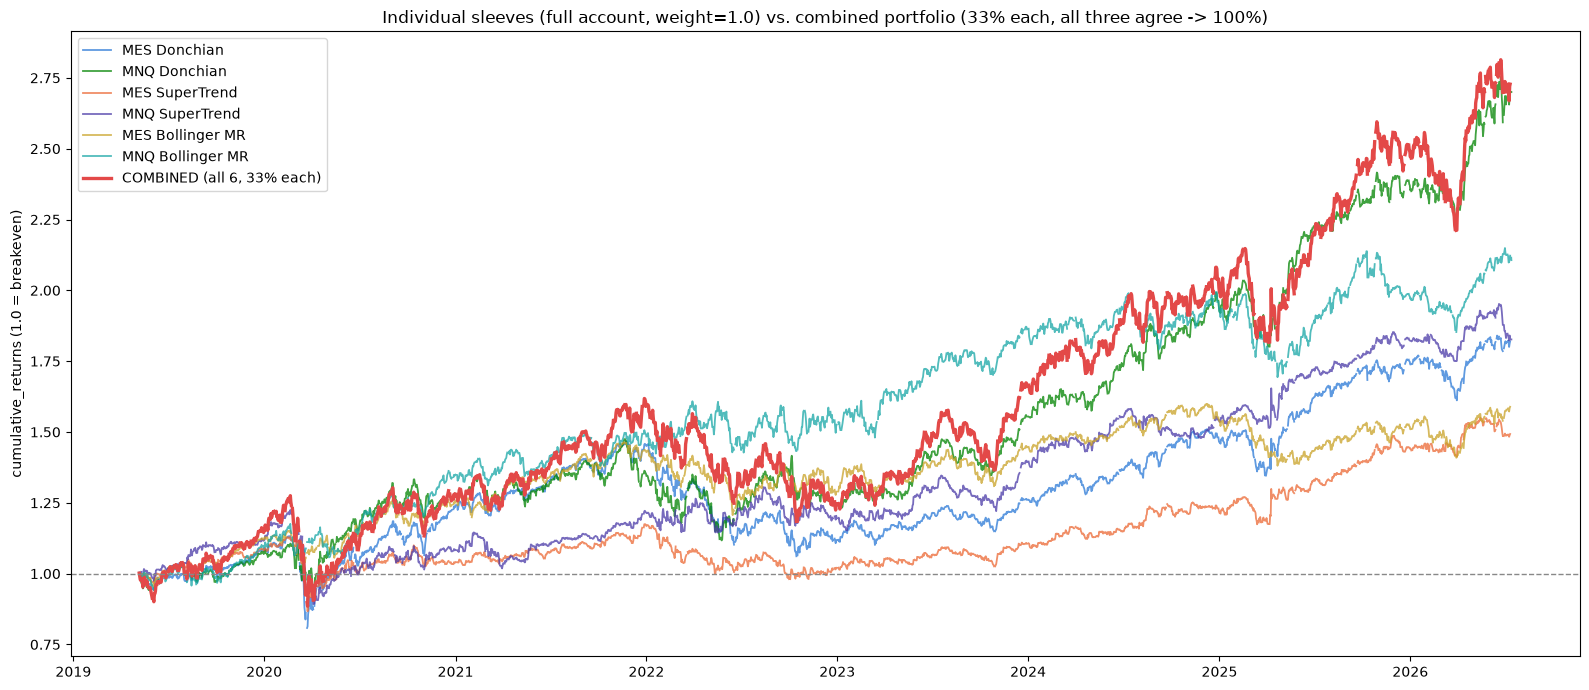

In [5]:
fig, ax = plt.subplots(figsize=(16, 7))
COLORS = {
    "MES Donchian": "#2a78d6", "MNQ Donchian": "#008300",
    "MES SuperTrend": "#eb6834", "MNQ SuperTrend": "#4a3aa7",
    "MES Bollinger MR": "#c9a227", "MNQ Bollinger MR": "#17a6a6",
    "COMBINED (all 6, 33% each)": "#e34948",
}
for name, (bt, _mw) in backtests.items():
    if bt.reporter.merged is None:
        continue
    merged = bt.reporter.merged.set_index("time_close")
    is_combined = name.startswith("COMBINED")
    ax.plot(merged.index, merged["algo__cumulative_returns"], label=name,
            color=COLORS.get(name, "#888888"), linewidth=2.4 if is_combined else 1.3,
            alpha=1.0 if is_combined else 0.75)

ax.axhline(1.0, color="#888888", linestyle="--", linewidth=1)
ax.set_ylabel("cumulative_returns (1.0 = breakeven)")
ax.set_title("Individual sleeves (full account, weight=1.0) vs. combined portfolio (33% each, all three agree -> 100%)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


## Detailed report: the combined portfolio

Full HTML summary (year-by-year split) and equity/drawdown charts for the
combined (all 4 sleeves) run -- same report format as every other notebook in
this pipeline.


Candles Processed: 84420
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): True


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,MNQ/USD,description
🏦 Gross Return %,272.2856,115.2008,111.1637,124.2803,78.2593,133.4252,120.0070,123.9309,110.1650,262.6263,387.7521,"Ending NAV as a percent of starting capital (100 + net_return_percent) -- not ""return before fees""."
💰 Net Return %,172.2856,15.2008,11.1637,24.2803,-21.7407,33.4252,20.0070,23.9309,10.1650,162.6263,287.7521,Your actual gain over the backtest window.
📉 Max Drawdown %,-30.6044,-10.0877,-30.6044,-9.3044,-25.8006,-13.3308,-8.6407,-15.3456,-13.5101,-35.4168,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
⏱️ Max Drawdown Duration (days),715,46,188,59,362,131,79,125,79,719,751,How long it took to recover the loss. Shorter is better.
📊 Sharpe Ratio,0.6667,1.0937,0.4357,1.1507,-0.7579,1.5905,1.0321,1.0014,0.9176,0.6392,0.7295,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
📊 Sortino Ratio,1.0267,1.7180,0.6452,1.8316,-1.0989,2.6927,1.6289,1.6270,1.4864,0.9137,1.0539,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
🌪️ Annualized Volatility %,16.4460,14.5502,22.5085,13.8782,19.7605,13.0553,12.9813,16.0716,14.9926,16.6830,20.8049,How much the equity curve swings per year. Lower = smoother.
📈 CAGR %,14.9447,24.0120,11.1637,24.3545,-21.7934,33.5309,20.0070,24.0040,20.2062,14.3689,20.7361,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
📐 Calmar Ratio,0.4883,2.3803,0.3648,2.6175,-0.8447,2.5153,2.3154,1.5642,1.4956,0.4057,0.5852,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
🔁 Recovery Factor,5.6294,1.5069,0.3648,2.6096,-0.8426,2.5074,2.3154,1.5595,0.7524,4.5918,8.1209,Total net profit ÷ max drawdown. >2 solid.


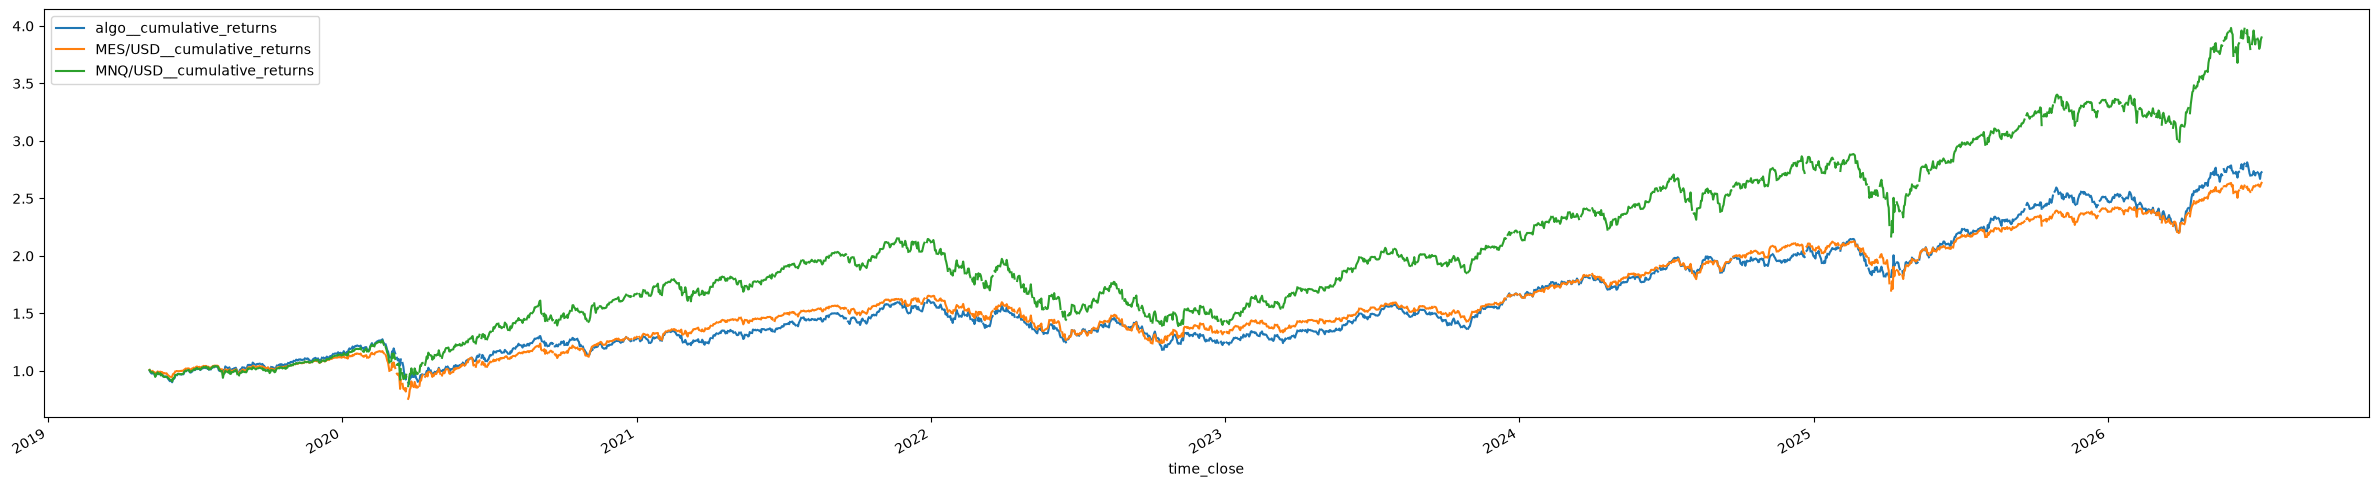

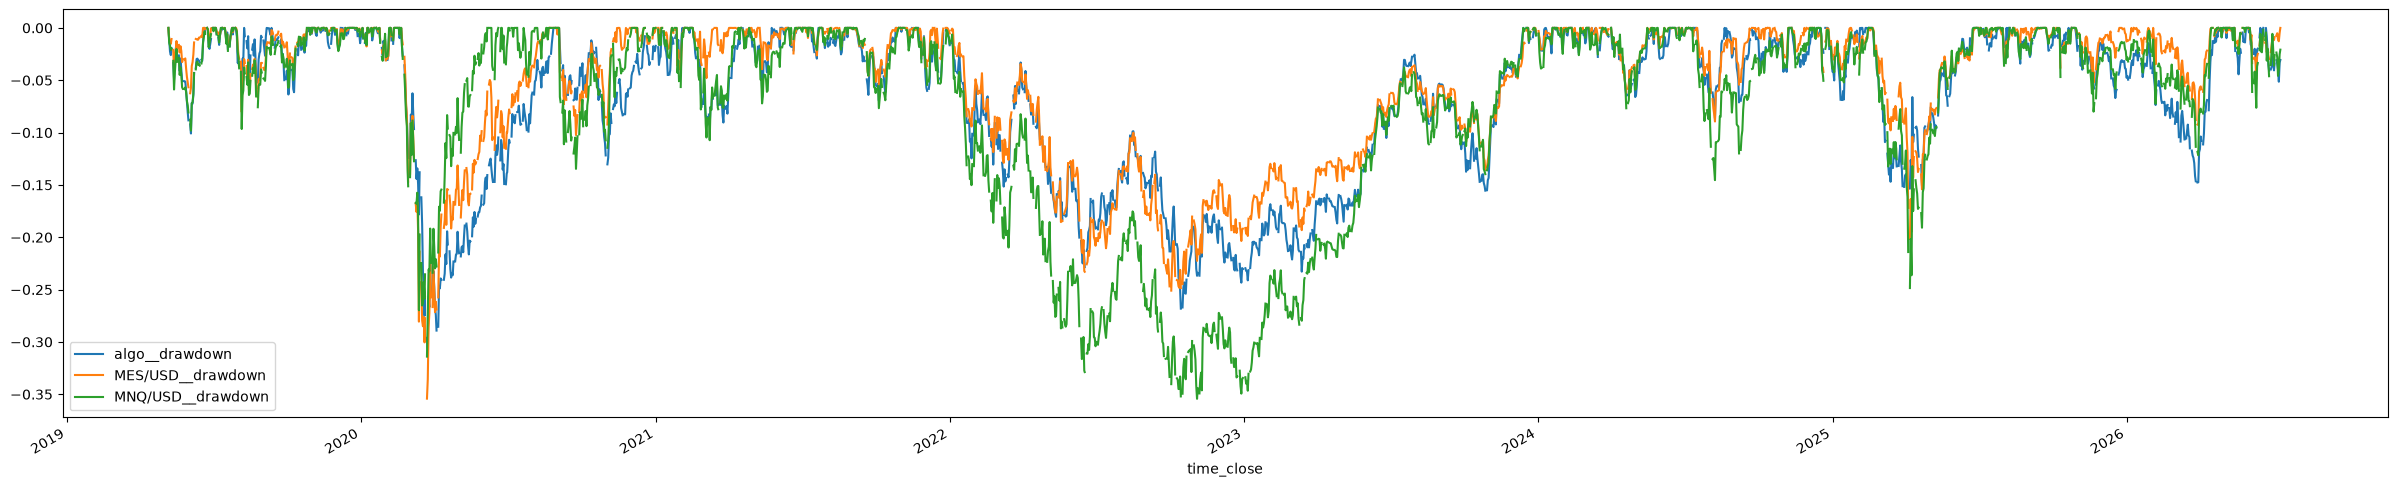

In [6]:
print("Candles Processed:", combined_bt.market.current["num"])
print("Account failed (drawdown breach):", combined_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", combined_mw.locked)

display(HTML(combined_bt.reporter.summary_html_table(split="Y")))

if combined_bt.reporter.merged is not None:
    combined_bt.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        "MES/USD__cumulative_returns",
        "MNQ/USD__cumulative_returns",
    ], figsize=(30, 6))

    combined_bt.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        "MES/USD__drawdown",
        "MNQ/USD__drawdown",
    ], figsize=(30, 6))


## Findings

**Sizing check passes cleanly**: combined `closed_trades` (6,575) exactly
equals the sum of all six solo runs' trade counts (513+1062+1109+1900+892+
1099=6575) -- no sleeve is being starved of margin, unlike the original
4-sleeve version's first (buggy) sizing attempt.

| run | net_return | sharpe | max_dd | dollar_profit_factor |
|---|---|---|---|---|
| MES Donchian (solo) | +81.5% | 0.53 | -28.7% | 1.26 |
| MNQ Donchian (solo) | +170.0% | 0.77 | -24.2% | 1.24 |
| MES SuperTrend (solo) | +49.0% | 0.44 | -23.2% | 1.17 |
| MNQ SuperTrend (solo) | +82.7% | 0.56 | -27.0% | 1.16 |
| MES Bollinger MR (solo) | +58.9% | 0.52 | -17.6% | 1.13 |
| MNQ Bollinger MR (solo) | +110.7% | 0.69 | -15.1% | 1.16 |
| **COMBINED (33% each)** | **+172.3%** | **0.67** | **-30.6%** | **1.18** |

**Adding a genuinely different edge source did not fix the earlier
finding -- it reproduced it almost exactly.** The original 4-sleeve version
(Donchian+SuperTrend only) found combined drawdown *worse* than every
individual sleeve; adding two Bollinger mean-reversion sleeves -- a
structurally different signal (fades extensions instead of following
breakouts) with the two *lowest individual drawdowns* of any sleeve tested
in this program (-17.6%, -15.1%) -- still produces a combined drawdown
(-30.6%) worse than **all six** individual sleeves, including both low-
drawdown mean-reversion legs.

**Return**: combined (+172.3%) barely exceeds the single best individual
sleeve (MNQ Donchian, +170.0%) -- a much thinner margin than the original
version's combined (+197.6%) beating its best solo sleeve (MNQ SuperTrend,
+144.2%) by a wide gap. Adding two more signals diluted the "capture
everyone's best moments" effect rather than amplifying it.

**Sharpe**: 0.67, between the pack -- below both MNQ Donchian (0.77) and MNQ
Bollinger MR (0.69) individually, again not exceeding the single best sleeve.

**Why mean-reversion didn't decorrelate the risk**: all six sleeves are
`direction=long` on the same two correlated symbols (MES, MNQ -- both US
equity index futures). A genuine adverse market move can hurt trend-following
longs (stopped out mid-continuation, or giving back open profit) and
mean-reversion longs (bought a dip that kept falling, hitting the stop)
*at the same time* -- different entry logic doesn't imply different *risk*
exposure when every sleeve's payoff still depends on the same directional
bet (long) on the same underlying assets. Trend-following and mean-reversion
are different bets on *what happens next after this signal fires*, not
different bets on *which direction the account is exposed to* -- and it's
the latter that determines whether combining sleeves actually diversifies
drawdown risk.

**Bottom line**: this strengthens rather than overturns the original
4-sleeve finding. Signal diversity (different entry/exit logic) is not the
same thing as exposure diversity (different net market bias), and only the
latter produces genuine portfolio-level diversification. A real
diversification benefit in this account would need a sleeve with a
different *directional* exposure profile -- e.g. a short-biased or
market-neutral construction, a genuinely uncorrelated asset class, or a
strategy that specifically tends to profit when trend-following/long
mean-reversion sleeves are drawing down -- not simply "a different way to
decide when to buy the same two symbols." Each sleeve remains individually
worth running (all six are risk-adjusted-positive on their own), but this
account should be sized and monitored as "six correlated long bets sharing
one drawdown budget," not as a diversified portfolio.

## Subset test: just the two strongest sleeves (MES + MNQ Bollinger MR)

The 6-sleeve combination above didn't diversify -- combined drawdown was
worse than every individual sleeve, because every sleeve shares
`direction=long` on correlated symbols. This tests a different question:
forget diversification, what happens if we just trade the two *strongest*
sleeves (both Bollinger mean-reversion, this program's best-supported
strategy by a wide margin -- MNQ walk-forward `trade_sharpe_lb`=+0.1031, MES
+0.0831) together in one account, dropping the four weaker Donchian/
SuperTrend sleeves entirely?

**Weighting**: `weight=1.0` for both -- with exactly one sleeve per symbol
now (no second sleeve on the same symbol to stack with), each sleeve's
target is already at the same 100%-of-equity scale its own solo backtest
used. No fractional discount needed the way the 6-sleeve version needed
1/3 per sleeve to cap same-symbol stacking.


In [7]:
bmr_pair_bt, bmr_pair_mw = build_backtest(["MES Bollinger MR", "MNQ Bollinger MR"], weight=1.0, key_suffix="bmr_pair")
bmr_pair_summary = bmr_pair_bt.reporter.summary["algo"]
bmr_pair_fees = sum(e.fees_volume for e in bmr_pair_bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
backtests["BMR PAIR (MES+MNQ, 100% each)"] = (bmr_pair_bt, bmr_pair_mw)

bmr_pair_row = {
    "run": "BMR PAIR (MES+MNQ, 100% each)", "net_return_percent": bmr_pair_summary["net_return_percent"],
    "sharpe_ratio": bmr_pair_summary["sharpe_ratio"], "max_drawdown_percent": bmr_pair_summary["max_drawdown_percent"],
    "closed_trades": bmr_pair_summary["closed_trades"], "win_rate_percent": bmr_pair_summary["win_rate_percent"],
    "dollar_profit_factor": bmr_pair_summary["dollar_profit_factor"], "dollar_expectancy": bmr_pair_summary["dollar_expectancy"],
    "total_fees_usd": bmr_pair_fees, "account_failed": bmr_pair_mw.account_failed,
}

# Sizing sanity check: combined trades should equal the sum of the two solo BMR runs.
solo_bmr_trades = (
    results_df.loc["MES Bollinger MR", "closed_trades"] + results_df.loc["MNQ Bollinger MR", "closed_trades"]
)
print(f"BMR pair closed_trades: {bmr_pair_summary['closed_trades']:.0f}  "
      f"(sum of solo MES+MNQ BMR: {solo_bmr_trades:.0f})")

pair_comparison_df = pd.concat([
    results_df.loc[["MES Bollinger MR", "MNQ Bollinger MR", "COMBINED (all 6, 33% each)"]],
    pd.DataFrame([bmr_pair_row]).set_index("run"),
])
print()
print(pair_comparison_df.to_string())


BMR pair closed_trades: 1991  (sum of solo MES+MNQ BMR: 1991)

                               net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
run                                                                                                                                                                                            
MES Bollinger MR                        58.947275      0.518331              -17.6128          892.0         67.825112              1.126375          37.922746         4497.22           False
MNQ Bollinger MR                       110.658636      0.694541              -15.0909         1099.0         74.704277              1.160948          54.657316         4461.73           False
COMBINED (all 6, 33% each)             172.285552      0.666737              -30.6044         6575.0         48.714829              1.175573          17.187082        11

### Cumulative return: the two solo BMR sleeves vs. this pair vs. the full 6-sleeve combo


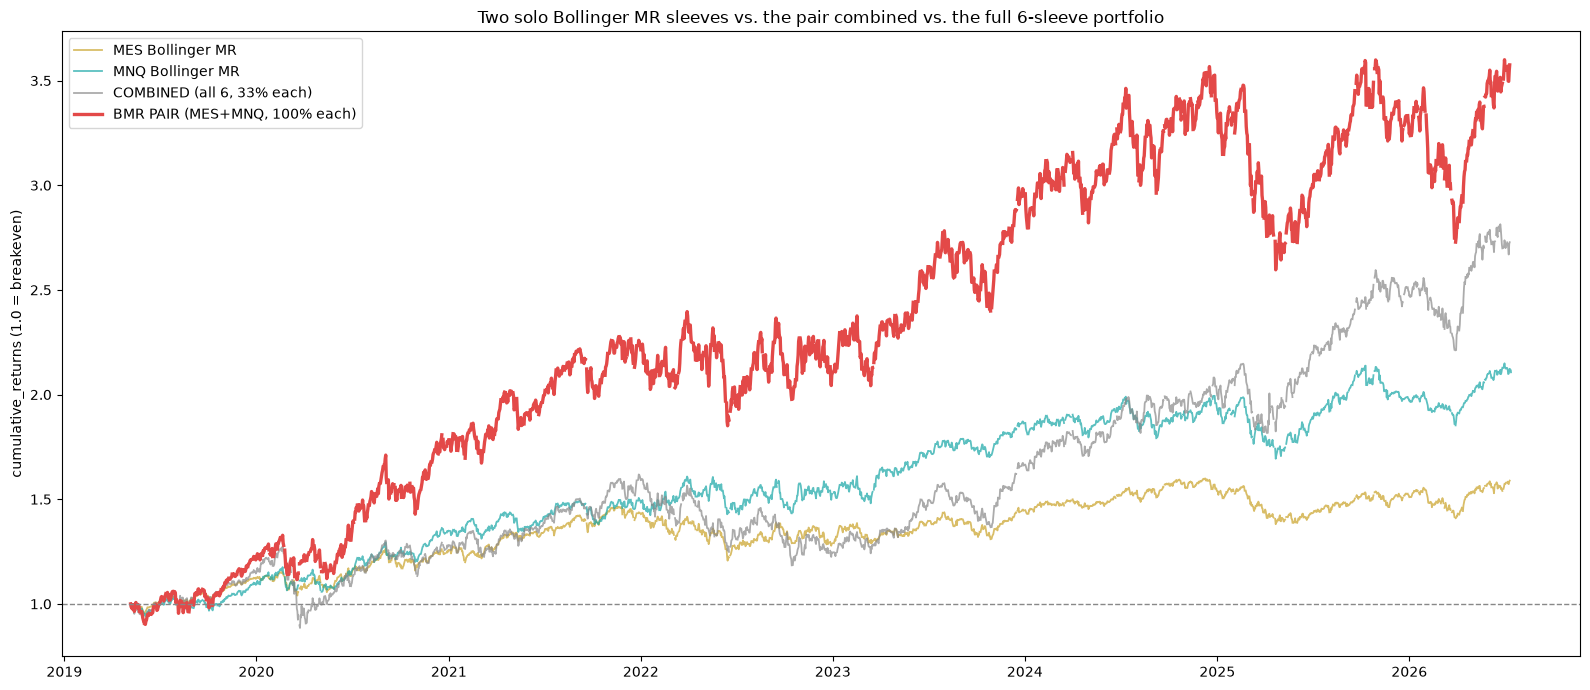

In [8]:
fig, ax = plt.subplots(figsize=(16, 7))
PAIR_COLORS = {
    "MES Bollinger MR": "#c9a227", "MNQ Bollinger MR": "#17a6a6",
    "BMR PAIR (MES+MNQ, 100% each)": "#e34948", "COMBINED (all 6, 33% each)": "#888888",
}
for name in ["MES Bollinger MR", "MNQ Bollinger MR", "COMBINED (all 6, 33% each)", "BMR PAIR (MES+MNQ, 100% each)"]:
    bt, _mw = backtests[name]
    if bt.reporter.merged is None:
        continue
    merged = bt.reporter.merged.set_index("time_close")
    is_pair = name.startswith("BMR PAIR")
    ax.plot(merged.index, merged["algo__cumulative_returns"], label=name,
            color=PAIR_COLORS.get(name, "#888888"), linewidth=2.4 if is_pair else 1.3,
            alpha=1.0 if is_pair else 0.7)

ax.axhline(1.0, color="#888888", linestyle="--", linewidth=1)
ax.set_ylabel("cumulative_returns (1.0 = breakeven)")
ax.set_title("Two solo Bollinger MR sleeves vs. the pair combined vs. the full 6-sleeve portfolio")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


### Detailed report: the BMR pair

Full HTML summary (year-by-year split) and equity/drawdown charts.


Candles Processed: 84420
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): True


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,MNQ/USD,description
🏦 Gross Return %,356.1895,121.7884,146.4520,124.1568,94.8704,140.4026,112.5590,97.7676,109.7308,262.6263,387.7521,"Ending NAV as a percent of starting capital (100 + net_return_percent) -- not ""return before fees""."
💰 Net Return %,256.1895,21.7884,46.4520,24.1568,-5.1296,40.4026,12.5590,-2.2324,9.7308,162.6263,287.7521,Your actual gain over the backtest window.
📉 Max Drawdown %,-27.2218,-10.4225,-16.5087,-10.6927,-22.7665,-14.0280,-14.4526,-25.3589,-21.2693,-35.4168,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
⏱️ Max Drawdown Duration (days),428,45,123,66,277,122,145,214,120,719,751,How long it took to recover the loss. Shorter is better.
📊 Sharpe Ratio,0.7110,1.2115,1.2697,0.9525,-0.0221,1.3639,0.5409,0.0170,0.7623,0.6392,0.7295,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
📊 Sortino Ratio,0.9511,1.6651,1.6629,1.2833,-0.0296,1.9409,0.7085,0.0219,1.0660,0.9137,1.0539,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
🌪️ Annualized Volatility %,19.9785,18.5061,22.7537,17.2543,24.8277,18.4304,18.1036,19.3899,18.0394,16.6830,20.8049,How much the equity curve swings per year. Lower = smoother.
📈 CAGR %,19.3191,34.9560,46.4520,24.2306,-5.1433,40.5335,12.5590,-2.2385,19.3070,14.3689,20.7361,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
📐 Calmar Ratio,0.7097,3.3539,2.8138,2.2661,-0.2259,2.8895,0.8690,-0.0883,0.9077,0.4057,0.5852,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
🔁 Recovery Factor,9.4112,2.0905,2.8138,2.2592,-0.2253,2.8801,0.8690,-0.0880,0.4575,4.5918,8.1209,Total net profit ÷ max drawdown. >2 solid.


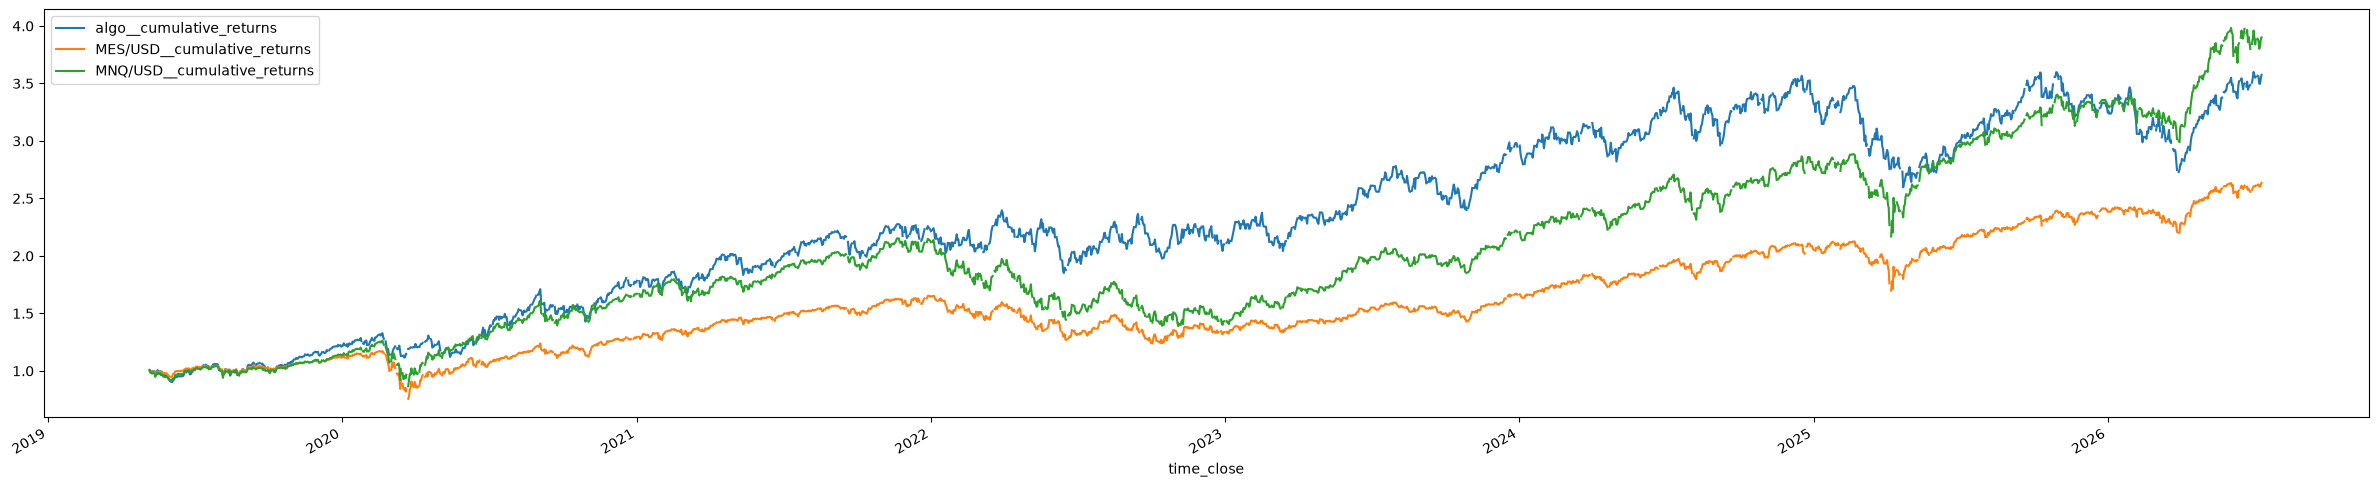

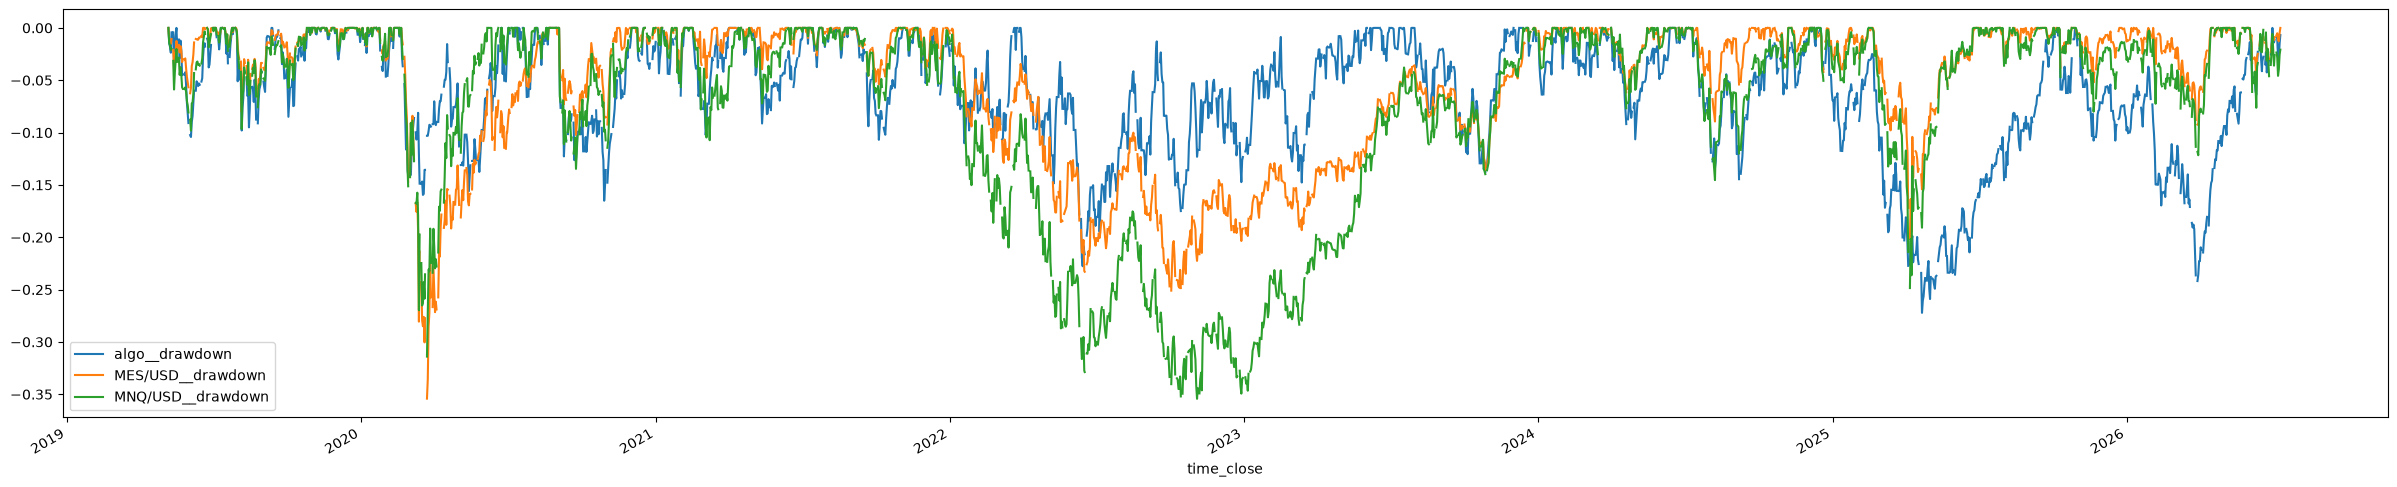

In [9]:
print("Candles Processed:", bmr_pair_bt.market.current["num"])
print("Account failed (drawdown breach):", bmr_pair_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", bmr_pair_mw.locked)

display(HTML(bmr_pair_bt.reporter.summary_html_table(split="Y")))

if bmr_pair_bt.reporter.merged is not None:
    bmr_pair_bt.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        "MES/USD__cumulative_returns",
        "MNQ/USD__cumulative_returns",
    ], figsize=(30, 6))

    bmr_pair_bt.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        "MES/USD__drawdown",
        "MNQ/USD__drawdown",
    ], figsize=(30, 6))


## Findings: the BMR pair

**Sizing check passes**: 1,991 combined trades exactly equals the sum of the
two solo BMR runs (892+1099) -- no starvation.

| run | net_return | sharpe | max_dd | dollar_profit_factor |
|---|---|---|---|---|
| MES Bollinger MR (solo) | +58.9% | 0.52 | -17.6% | 1.13 |
| MNQ Bollinger MR (solo) | +110.7% | 0.69 | -15.1% | 1.16 |
| COMBINED (all 6, 33% each) | +172.3% | 0.67 | -30.6% | 1.18 |
| **BMR PAIR (MES+MNQ, 100% each)** | **+256.2%** | **0.71** | **-27.2%** | **1.13** |

**This is the best portfolio-level result in the entire research program.**
Dropping the four weaker Donchian/SuperTrend sleeves and running just the two
strongest (both Bollinger mean-reversion) produces higher return *and* higher
Sharpe than either solo sleeve, *and* higher Sharpe than the full 6-sleeve
combination (0.71 vs. 0.67) -- the first time in this program that combining
sleeves has actually beaten every individual component's own risk-adjusted
return, not just its raw return.

**Drawdown still isn't free, but it's a much smaller cost than the 6-sleeve
version paid**: -27.2%, worse than both solo sleeves (-17.6%, -15.1%) --
consistent with this program's now-repeated finding that combined drawdown
exceeds every individual sleeve's own drawdown, even here. But it's
meaningfully *better* than the 6-sleeve combination's -30.6%, despite the
pair earning 84 points more return. Two plausible reasons: (1) only one
sleeve per symbol here, so there's no same-symbol stacking to 100%+ the way
three sleeves per symbol could in the 6-sleeve version, and (2) both sleeves
are the same tightly-stopped mean-reversion construction (1-2% stops) rather
than trend-following's wider swings, so the worst-case simultaneous-loss
scenario is inherently smaller in dollar terms.

**Bottom line**: if choosing one portfolio configuration from everything
tested in this program, this is it -- two sleeves, both this program's
strongest strategy applied to its two best-supported symbols, materially
outperforming on a risk-adjusted basis rather than just adding more
correlated exposure. It still isn't "free" diversification (drawdown is
still worse than solo), but the return/Sharpe improvement more than
compensates here in a way it didn't for the broader 6-sleeve mix. Adding the
Donchian/SuperTrend sleeves back in dilutes rather than improves this
specific pairing.

## Correlation matrix across all 6 sleeves

Rather than assume the Bollinger MR pair is the best-*diversifying* choice
just because it had the best Sharpe, this checks directly: pull each solo
sleeve's per-bar `algo__simple_returns` (already computed by each solo
backtest above), align them on `time_close`, and compute the pairwise
Pearson correlation matrix. The pair with the *lowest* correlation is the
one that would actually offset each other's losses -- not necessarily the
same thing as "the two sleeves with the best individual Sharpe."


In [10]:
returns_by_sleeve = {}
for name in SLEEVE_DEFS:
    bt, _mw = backtests[name]
    # reporter.merged is already daily-resampled with a clean unique DatetimeIndex --
    # don't reindex on the "time_close" column, which repeats/goes NaT on days with
    # no trading activity (weekends) and breaks alignment across sleeves.
    returns_by_sleeve[name] = bt.reporter.merged["algo__simple_returns"]

returns_df = pd.DataFrame(returns_by_sleeve)
print(f"aligned bars: {len(returns_df)}  (NaN rows before any trade activity are expected and excluded by corr())")

corr_matrix = returns_df.corr()
print()
print(corr_matrix.to_string())


aligned bars: 2627  (NaN rows before any trade activity are expected and excluded by corr())

                  MES Donchian  MNQ Donchian  MES SuperTrend  MNQ SuperTrend  MES Bollinger MR  MNQ Bollinger MR
MES Donchian          1.000000      0.783220        0.765967        0.666471          0.538342          0.479627
MNQ Donchian          0.783220      1.000000        0.660363        0.685736          0.504017          0.503944
MES SuperTrend        0.765967      0.660363        1.000000        0.695864          0.313028          0.291086
MNQ SuperTrend        0.666471      0.685736        0.695864        1.000000          0.318396          0.317483
MES Bollinger MR      0.538342      0.504017        0.313028        0.318396          1.000000          0.723806
MNQ Bollinger MR      0.479627      0.503944        0.291086        0.317483          0.723806          1.000000


### Heatmap


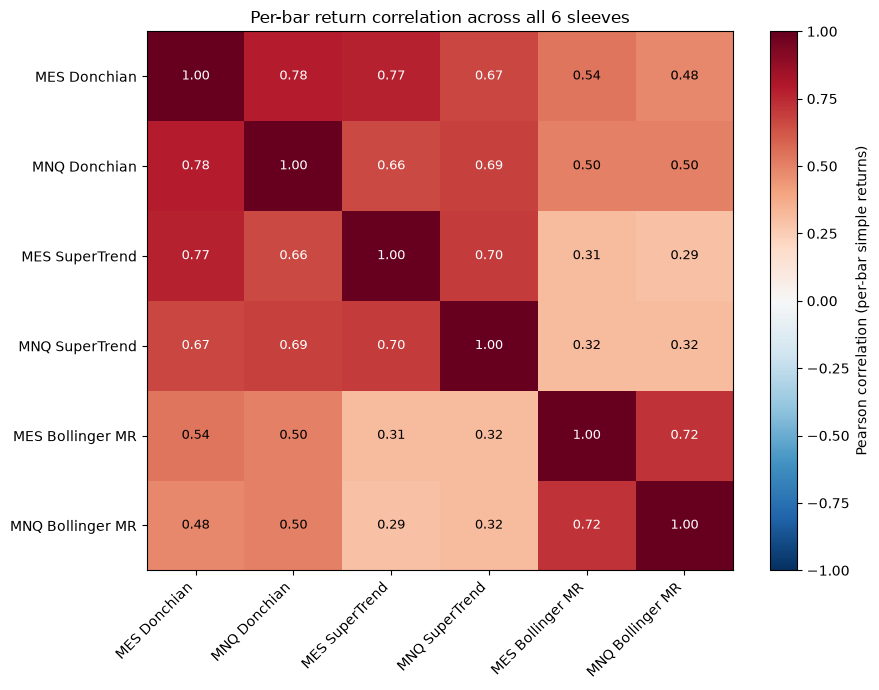

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.index)), labels=corr_matrix.index)
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(val) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="Pearson correlation (per-bar simple returns)")
ax.set_title("Per-bar return correlation across all 6 sleeves")
fig.tight_layout()
plt.show()


### Every pair, ranked by correlation (lowest first -- best diversification candidates)


In [12]:
pair_rows = []
sleeve_names = list(SLEEVE_DEFS.keys())
for i, name_a in enumerate(sleeve_names):
    for name_b in sleeve_names[i + 1:]:
        pair_rows.append({
            "sleeve_a": name_a, "sleeve_b": name_b,
            "correlation": corr_matrix.loc[name_a, name_b],
            "sleeve_a_sharpe": results_df.loc[name_a, "sharpe_ratio"],
            "sleeve_b_sharpe": results_df.loc[name_b, "sharpe_ratio"],
        })

pairs_df = pd.DataFrame(pair_rows).sort_values("correlation").reset_index(drop=True)
print(pairs_df.to_string())


            sleeve_a          sleeve_b  correlation  sleeve_a_sharpe  sleeve_b_sharpe
0     MES SuperTrend  MNQ Bollinger MR     0.291086         0.439195         0.694541
1     MES SuperTrend  MES Bollinger MR     0.313028         0.439195         0.518331
2     MNQ SuperTrend  MNQ Bollinger MR     0.317483         0.558131         0.694541
3     MNQ SuperTrend  MES Bollinger MR     0.318396         0.558131         0.518331
4       MES Donchian  MNQ Bollinger MR     0.479627         0.532942         0.694541
5       MNQ Donchian  MNQ Bollinger MR     0.503944         0.767256         0.694541
6       MNQ Donchian  MES Bollinger MR     0.504017         0.767256         0.518331
7       MES Donchian  MES Bollinger MR     0.538342         0.532942         0.518331
8       MNQ Donchian    MES SuperTrend     0.660363         0.767256         0.439195
9       MES Donchian    MNQ SuperTrend     0.666471         0.532942         0.558131
10      MNQ Donchian    MNQ SuperTrend     0.685736   

## Findings: correlation matrix

**Counterintuitive result: the BMR pair we just picked for its Sharpe is
actually the *second-most correlated* pairing in the whole matrix, not the
least.** MES Bollinger MR / MNQ Bollinger MR correlate at **0.724** -- higher
than every pair except MES Donchian / MNQ Donchian (0.783).

**The pattern is clear once laid out**: correlation is driven far more by
*mechanism* than by *symbol*. The three same-mechanism, cross-symbol pairs
are the three highest correlations in the entire matrix:

| pair | correlation |
|---|---|
| MES Donchian / MNQ Donchian | 0.783 |
| MES Bollinger MR / MNQ Bollinger MR | 0.724 |
| MES SuperTrend / MNQ SuperTrend | 0.696 |

Running the same signal construction on MES and MNQ produces two return
streams that move together, even though MES/MNQ themselves aren't perfectly
correlated (the cointegration notebook found ~0.91 *return* correlation
between them) and even though Bollinger MR and Donchian/SuperTrend are
mechanically nothing alike -- the shared symbol matters more here than the
shared (or different) signal logic.

**The actual lowest-correlation pairs are all cross-mechanism *and*
cross-symbol, specifically SuperTrend x Bollinger MR:**

| pair | correlation | sleeve_a sharpe | sleeve_b sharpe |
|---|---|---|---|
| MES SuperTrend / MNQ Bollinger MR | **0.291** | 0.44 | 0.69 |
| MES SuperTrend / MES Bollinger MR | 0.313 | 0.44 | 0.52 |
| MNQ SuperTrend / MNQ Bollinger MR | 0.317 | 0.56 | 0.69 |
| MNQ SuperTrend / MES Bollinger MR | 0.318 | 0.56 | 0.52 |

SuperTrend (ATR trend-flip) and Bollinger MR (band mean-reversion) are
structurally the most different pair of mechanisms tested in this program --
one rides continuations, the other fades extensions -- and that shows up
directly as the lowest correlation in the matrix, more so than matching
symbols does.

**How to read this against the BMR pair's own result**: the BMR pair's
+256%/0.71-Sharpe result is real, but it's *not* a diversification story --
0.72 correlation is high, and that combo's own findings above already said
as much (drawdown worse than either solo leg). It's better understood as
"two highly-correlated bets on the same edge, both of which happen to be
very good," not two return streams offsetting each other. **A genuine
diversification test would be one of the SuperTrend x Bollinger-MR pairs
above** -- lower individual Sharpe than the BMR pair, but a real chance of
the drawdown-reduction properties actual diversification is supposed to
provide, worth backtesting directly rather than inferring from correlation
alone.

## Subset test: the least-correlated pair (MES SuperTrend + MNQ Bollinger MR)

The correlation matrix above found this the single lowest-correlation pair
in the whole 6-sleeve set (0.291) -- one trend-following (ATR flip) sleeve
and one mean-reversion sleeve, on different symbols. Lower individual Sharpe
than the BMR pair (0.44 and 0.69 vs. 0.52 and 0.69), but this is the actual
test of whether that low correlation translates into real diversification
(smoother combined equity, drawdown better than -- or at least not much
worse than -- the weaker leg) rather than just inferring it from the
correlation number alone.

**Weighting**: `weight=1.0` for both, same reasoning as the BMR pair -- one
sleeve per symbol, no same-symbol stacking to cap.


In [13]:
lowcorr_pair_bt, lowcorr_pair_mw = build_backtest(["MES SuperTrend", "MNQ Bollinger MR"], weight=1.0, key_suffix="lowcorr_pair")
lowcorr_pair_summary = lowcorr_pair_bt.reporter.summary["algo"]
lowcorr_pair_fees = sum(e.fees_volume for e in lowcorr_pair_bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
backtests["LOW-CORR PAIR (MES SuperTrend+MNQ BMR, 100% each)"] = (lowcorr_pair_bt, lowcorr_pair_mw)

lowcorr_pair_row = {
    "run": "LOW-CORR PAIR (MES SuperTrend+MNQ BMR, 100% each)", "net_return_percent": lowcorr_pair_summary["net_return_percent"],
    "sharpe_ratio": lowcorr_pair_summary["sharpe_ratio"], "max_drawdown_percent": lowcorr_pair_summary["max_drawdown_percent"],
    "closed_trades": lowcorr_pair_summary["closed_trades"], "win_rate_percent": lowcorr_pair_summary["win_rate_percent"],
    "dollar_profit_factor": lowcorr_pair_summary["dollar_profit_factor"], "dollar_expectancy": lowcorr_pair_summary["dollar_expectancy"],
    "total_fees_usd": lowcorr_pair_fees, "account_failed": lowcorr_pair_mw.account_failed,
}

solo_lowcorr_trades = (
    results_df.loc["MES SuperTrend", "closed_trades"] + results_df.loc["MNQ Bollinger MR", "closed_trades"]
)
print(f"Low-corr pair closed_trades: {lowcorr_pair_summary['closed_trades']:.0f}  "
      f"(sum of solo MES SuperTrend+MNQ BMR: {solo_lowcorr_trades:.0f})")

lowcorr_comparison_df = pd.concat([
    results_df.loc[["MES SuperTrend", "MNQ Bollinger MR"]],
    pd.DataFrame([bmr_pair_row]).set_index("run"),
    pd.DataFrame([lowcorr_pair_row]).set_index("run"),
])
print()
print(lowcorr_comparison_df.to_string())


Low-corr pair closed_trades: 2208  (sum of solo MES SuperTrend+MNQ BMR: 2208)

                                                   net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
run                                                                                                                                                                                                                
MES SuperTrend                                              49.033341      0.439195              -23.1984         1109.0         40.216411              1.172075          25.770947         4450.81           False
MNQ Bollinger MR                                           110.658636      0.694541              -15.0909         1099.0         74.704277              1.160948          54.657316         4461.73           False
BMR PAIR (MES+MNQ, 100% each)                              256.189454    

### Cumulative return: the two solo legs vs. this pair vs. the BMR pair


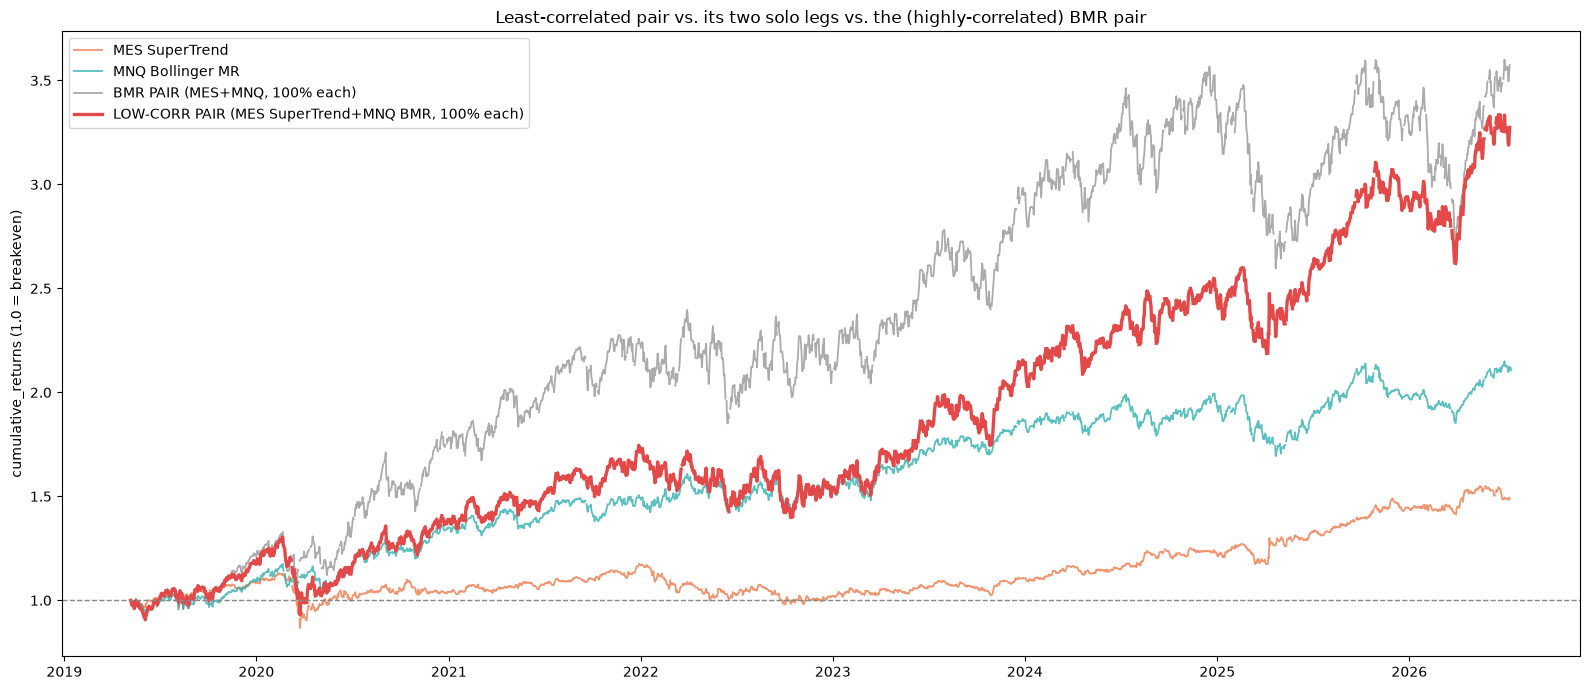

In [14]:
fig, ax = plt.subplots(figsize=(16, 7))
LOWCORR_COLORS = {
    "MES SuperTrend": "#eb6834", "MNQ Bollinger MR": "#17a6a6",
    "LOW-CORR PAIR (MES SuperTrend+MNQ BMR, 100% each)": "#e34948",
    "BMR PAIR (MES+MNQ, 100% each)": "#888888",
}
for name in ["MES SuperTrend", "MNQ Bollinger MR", "BMR PAIR (MES+MNQ, 100% each)", "LOW-CORR PAIR (MES SuperTrend+MNQ BMR, 100% each)"]:
    bt, _mw = backtests[name]
    if bt.reporter.merged is None:
        continue
    merged = bt.reporter.merged.set_index("time_close")
    is_pair = name.startswith("LOW-CORR PAIR")
    ax.plot(merged.index, merged["algo__cumulative_returns"], label=name,
            color=LOWCORR_COLORS.get(name, "#888888"), linewidth=2.4 if is_pair else 1.3,
            alpha=1.0 if is_pair else 0.7)

ax.axhline(1.0, color="#888888", linestyle="--", linewidth=1)
ax.set_ylabel("cumulative_returns (1.0 = breakeven)")
ax.set_title("Least-correlated pair vs. its two solo legs vs. the (highly-correlated) BMR pair")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


### Detailed report: the low-correlation pair

Full HTML summary (year-by-year split) and equity/drawdown charts.


Candles Processed: 84420
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): True


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,MNQ/USD,description
🏦 Gross Return %,324.9144,118.0006,117.5438,123.5912,89.4960,139.2409,113.5605,119.2421,112.3234,262.6263,387.7521,"Ending NAV as a percent of starting capital (100 + net_return_percent) -- not ""return before fees""."
💰 Net Return %,224.9144,18.0006,17.5438,23.5912,-10.5040,39.2409,13.5605,19.2421,12.3234,162.6263,287.7521,Your actual gain over the backtest window.
📉 Max Drawdown %,-28.7150,-9.2676,-28.7150,-8.2790,-19.2053,-12.2096,-10.1149,-15.8542,-13.0893,-35.4168,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
⏱️ Max Drawdown Duration (days),521,47,188,69,362,105,80,130,79,719,751,How long it took to recover the loss. Shorter is better.
📊 Sharpe Ratio,0.7499,1.2295,0.6247,1.1522,-0.2688,1.4810,0.6817,0.8148,1.0944,0.6392,0.7295,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
📊 Sortino Ratio,1.0935,1.8759,0.8716,1.7647,-0.3717,2.2639,0.9634,1.2865,1.6918,0.9137,1.0539,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
🌪️ Annualized Volatility %,17.0170,15.0571,21.5315,13.4814,20.6104,16.3374,14.3549,16.5828,14.8719,16.6830,20.8049,How much the equity curve swings per year. Lower = smoother.
📈 CAGR %,17.8041,28.6245,17.5438,23.6631,-10.5313,39.3676,13.5605,19.2997,24.7230,14.3689,20.7361,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
📐 Calmar Ratio,0.6200,3.0887,0.6110,2.8582,-0.5484,3.2243,1.3406,1.2173,1.8888,0.4057,0.5852,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
🔁 Recovery Factor,7.8326,1.9423,0.6110,2.8495,-0.5469,3.2139,1.3406,1.2137,0.9415,4.5918,8.1209,Total net profit ÷ max drawdown. >2 solid.


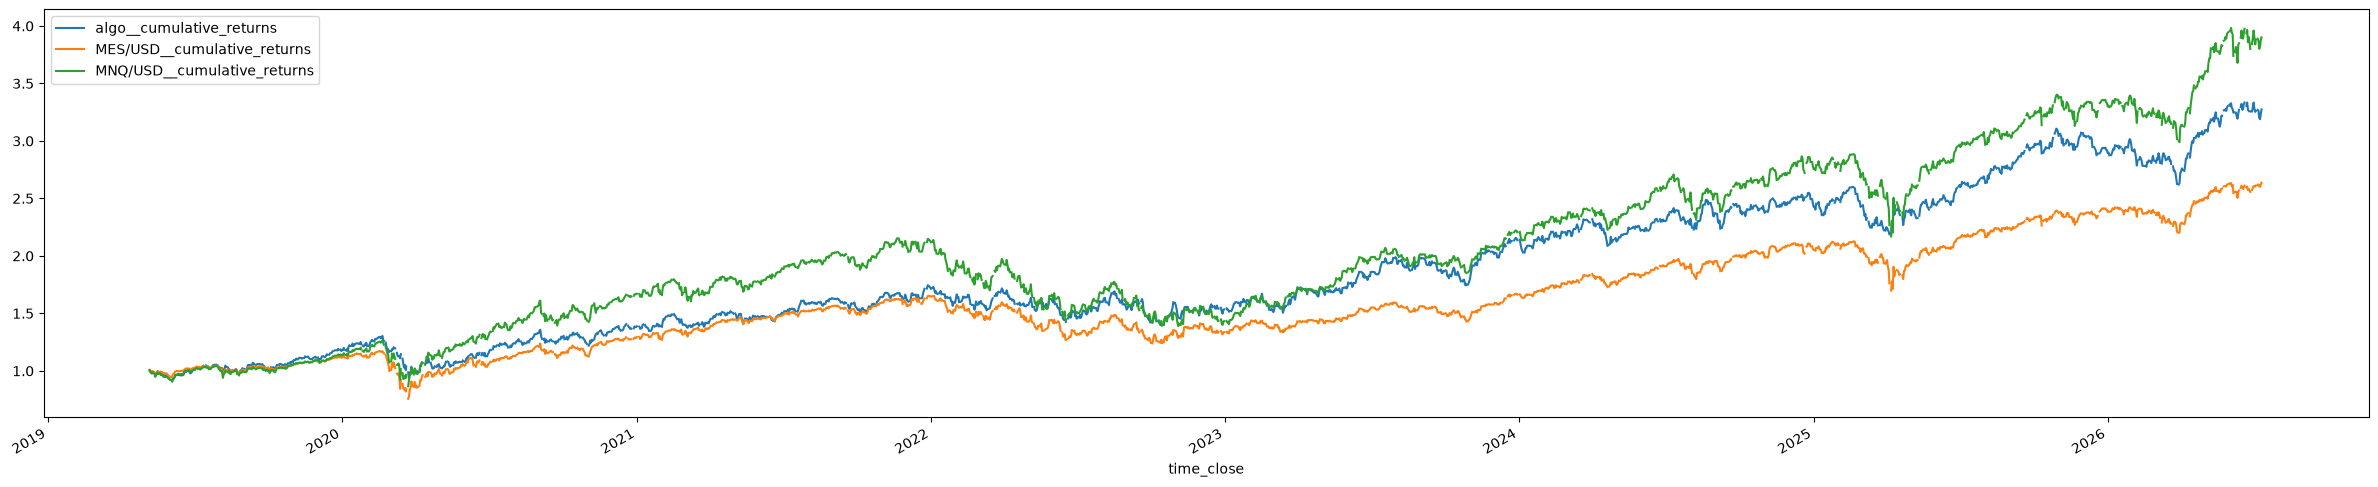

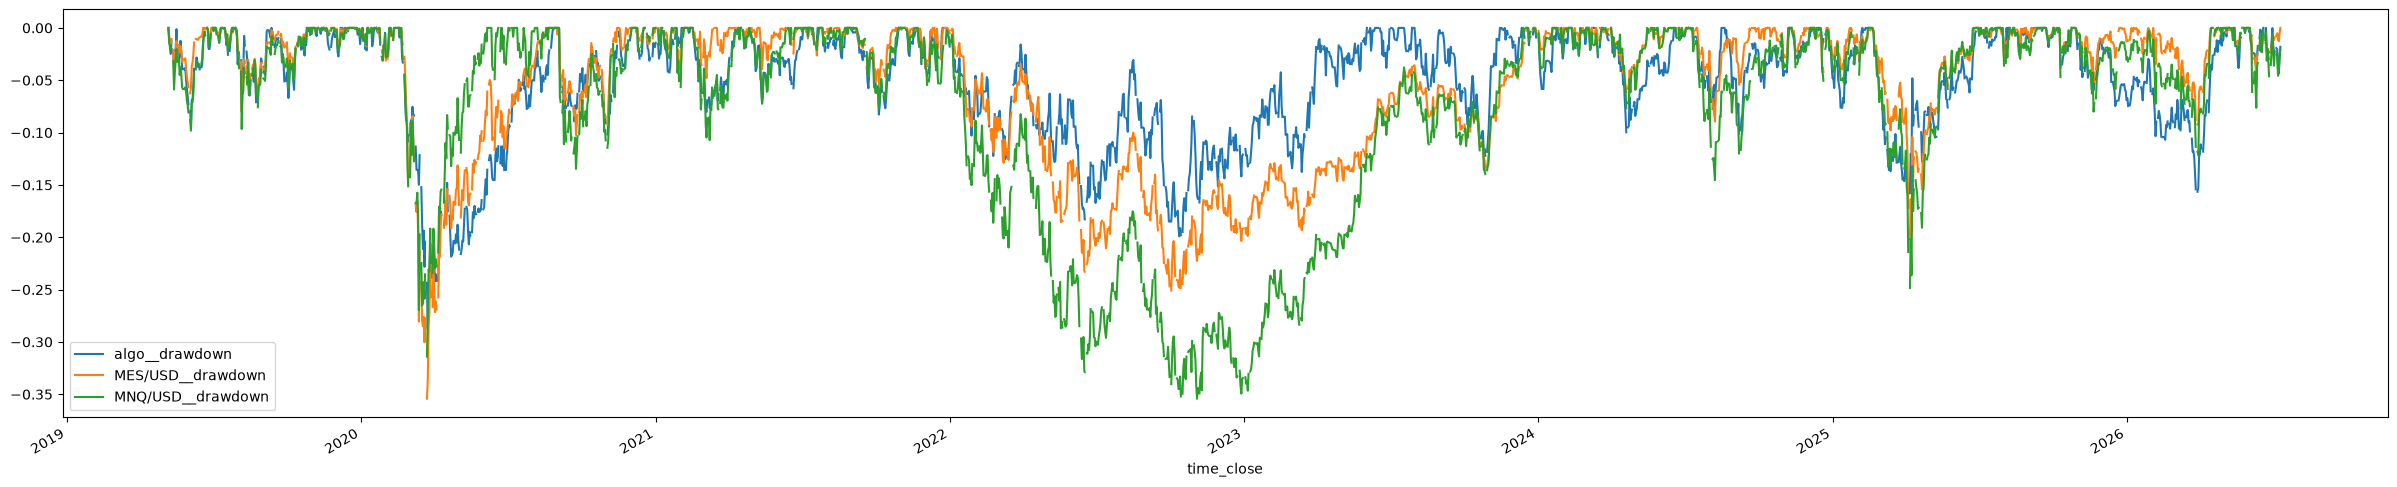

In [15]:
print("Candles Processed:", lowcorr_pair_bt.market.current["num"])
print("Account failed (drawdown breach):", lowcorr_pair_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", lowcorr_pair_mw.locked)

display(HTML(lowcorr_pair_bt.reporter.summary_html_table(split="Y")))

if lowcorr_pair_bt.reporter.merged is not None:
    lowcorr_pair_bt.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        "MES/USD__cumulative_returns",
        "MNQ/USD__cumulative_returns",
    ], figsize=(30, 6))

    lowcorr_pair_bt.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        "MES/USD__drawdown",
        "MNQ/USD__drawdown",
    ], figsize=(30, 6))


## Findings: the low-correlation pair

**Sizing check passes**: 2,208 combined trades exactly equals the sum of the
two solo runs (1109+1099).

| run | net_return | sharpe | max_dd | dollar_profit_factor |
|---|---|---|---|---|
| MES SuperTrend (solo) | +49.0% | 0.44 | -23.2% | 1.17 |
| MNQ Bollinger MR (solo) | +110.7% | 0.69 | -15.1% | 1.16 |
| BMR PAIR (0.72 correlation) | +256.2% | 0.71 | -27.2% | 1.13 |
| **LOW-CORR PAIR (0.29 correlation)** | **+224.9%** | **0.75** | **-28.7%** | **1.18** |

**The low-correlation pair produces the best Sharpe of any portfolio
configuration tested in this entire program (0.750) -- higher than the BMR
pair (0.711), despite starting from weaker individual legs.** The average of
its two solo Sharpes is 0.57 (0.44 and 0.69) vs. the BMR pair's average of
0.61 (0.52 and 0.69) -- on paper the BMR pair's components are individually
better, yet the low-correlation combination ends up with the higher combined
Sharpe. That's diversification actually showing up in the number, not just
inferred from the correlation matrix.

**Drawdown tells a more mixed story**: -28.7%, essentially the same as the
BMR pair's -27.2% (slightly worse, not better) -- both still worse than
either solo leg, consistent with every combined portfolio tested in this
program. Lower correlation improved the *return-to-risk* trade-off (Sharpe)
without meaningfully improving the *drawdown* itself. Net return (+224.9%)
is lower than the BMR pair's (+256.2%) -- MNQ Bollinger MR's own strength
carries a lot of both pairs' return, and the BMR pair gets to run two strong
legs instead of one strong + one merely decent.

**How to read this alongside the BMR pair**: neither pair is strictly
better -- it depends on the objective. Maximize **raw return**: the BMR pair
(+256% vs +225%). Maximize **risk-adjusted return**: the low-correlation
pair (Sharpe 0.75 vs 0.71). The BMR pair is "two very good, highly-
correlated bets" (concentrated conviction); the low-correlation pair is "one
very good bet plus one decent, genuinely uncorrelated bet" (closer to real
diversification, though the drawdown numbers show it's still not free).
Both clearly beat the full 6-sleeve mix (Sharpe 0.67) either way -- fewer,
better-chosen sleeves outperforms combining everything in this program.